In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
import os
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score, auc, f1_score
from sklearn.model_selection import train_test_split

In [99]:
df_a_o_a_f = pd.read_csv("../data/data_cleaned_with_all_outliers_and_all_features.csv", index_col=0)
df_a_o_a_f.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2


In [100]:
df_n_o_s_f = pd.read_csv("../data/data_cleaned_selected_with_no_outliers.csv", index_col=0)
df_n_o_s_f.head()

,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (enrolled),Tuition fees up to date,Scholarship holder,Target
0,0,0.000000,0,1,0,0
1,6,13.666667,6,0,0,2
2,0,0.000000,6,0,0,0
3,5,12.400000,6,1,0,2
4,6,13.000000,6,1,0,2


In [101]:
X_a_o_a_f = df_a_o_a_f.drop(columns=['Target'])
y_a_o_a_f = df_a_o_a_f['Target']
X_n_o_s_f = df_n_o_s_f.drop(columns=['Target'])
y_n_o_s_f = df_n_o_s_f['Target']

X_train_a_o_a_f, X_test_a_o_a_f, y_train_a_o_a_f, y_test_a_o_a_f = train_test_split(X_a_o_a_f, y_a_o_a_f, test_size=0.2, random_state=42, stratify=y_a_o_a_f)
X_train_n_o_s_f, X_test_n_o_s_f, y_train_n_o_s_f, y_test_n_o_s_f = train_test_split(X_n_o_s_f, y_n_o_s_f, test_size=0.2, random_state=42, stratify=y_n_o_s_f)

In [102]:
RF_DIR  = "../models/random_forest_classifier_model"
DT_DIR  = "../models/decision_tree_classifier_model"
XGB_DIR = "../models/xgboost_classifier_model"
best_rf_model  = joblib.load(os.path.join(RF_DIR,  [f for f in os.listdir(RF_DIR)  if f.endswith('.pkl')][0]))
best_dt_model  = joblib.load(os.path.join(DT_DIR,  [f for f in os.listdir(DT_DIR)  if f.endswith('.pkl')][0]))
best_xgb_model = joblib.load(os.path.join(XGB_DIR, [f for f in os.listdir(XGB_DIR) if f.endswith('.pkl')][0]))

print("✅ RF MODEL LOADED :", type(best_rf_model).__name__)
print("✅ DT MODEL LOADED :", type(best_dt_model).__name__)
print("✅ XGB MODEL LOADED :", type(best_xgb_model).__name__)

✅ RF MODEL LOADED : RandomForestClassifier
✅ DT MODEL LOADED : DecisionTreeClassifier
✅ XGB MODEL LOADED : XGBClassifier


In [103]:
rf_pred  = best_rf_model.predict(X_test_a_o_a_f)
dt_pred  = best_dt_model.predict(X_test_n_o_s_f)
xgb_pred = best_xgb_model.predict(X_test_a_o_a_f)

rf_proba  = best_rf_model.predict_proba(X_test_a_o_a_f)
dt_proba  = best_dt_model.predict_proba(X_test_n_o_s_f)
xgb_proba = best_xgb_model.predict_proba(X_test_a_o_a_f)

In [104]:
models_eval = [
    ("Random Forest",  y_test_a_o_a_f, rf_pred,  rf_proba),
    ("Decision Tree",  y_test_n_o_s_f, dt_pred,  dt_proba),
    ("XGBoost",        y_test_a_o_a_f, xgb_pred, xgb_proba),
]

results = []
for name, y_test, y_pred, y_proba in models_eval:
    results.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'F1 (Macro)': round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 (Weighted)': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_proba, multi_class='ovr'), 4),
    })

df_results = pd.DataFrame(results).set_index('Model')
print("="*60)
print("MODEL COMPARISON — METRICS SUMMARY")
print("="*60)
print(df_results.to_string())
print("="*60)
print()
print("="*60)
# Highlight best per column
print("🏆 BEST PER METRIC:")
print("="*60)
for col in df_results.columns:
    print(f"   {col:20s}: {df_results[col].idxmax()} ({df_results[col].max():.4f})")
print("="*60)

MODEL COMPARISON — METRICS SUMMARY
               Accuracy  F1 (Macro)  F1 (Weighted)  ROC-AUC
Model                                                      
Random Forest    0.9492      0.9384         0.9488   0.9889
Decision Tree    0.7463      0.6740         0.7414   0.8502
XGBoost          0.8384      0.7938         0.8336   0.9426

🏆 BEST PER METRIC:
   Accuracy            : Random Forest (0.9492)
   F1 (Macro)          : Random Forest (0.9384)
   F1 (Weighted)       : Random Forest (0.9488)
   ROC-AUC             : Random Forest (0.9889)


In [105]:
for name, y_test, y_pred, _ in models_eval:
    print('='*60)
    print(f"CLASSIFICATION REPORT — {name}")
    print('='*60)
    print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       284
           1       0.92      0.88      0.90       159
           2       0.95      0.98      0.97       442

    accuracy                           0.95       885
   macro avg       0.94      0.93      0.94       885
weighted avg       0.95      0.95      0.95       885

CLASSIFICATION REPORT — Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.71      0.77       279
           1       0.43      0.39      0.41       155
           2       0.79      0.90      0.84       433

    accuracy                           0.75       867
   macro avg       0.69      0.67      0.67       867
weighted avg       0.74      0.75      0.74       867

CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       284
           1       0.

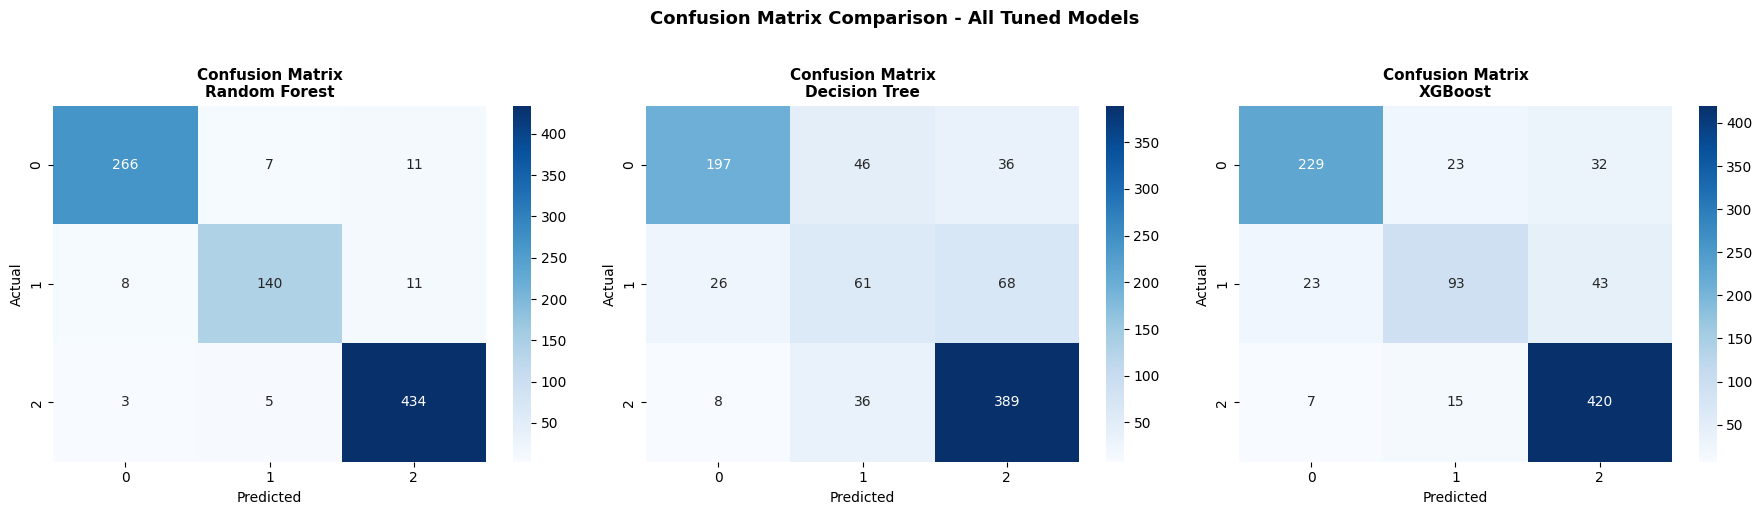

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, y_test, y_pred, _) in enumerate(models_eval):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f"Confusion Matrix\n{name}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison - All Tuned Models", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

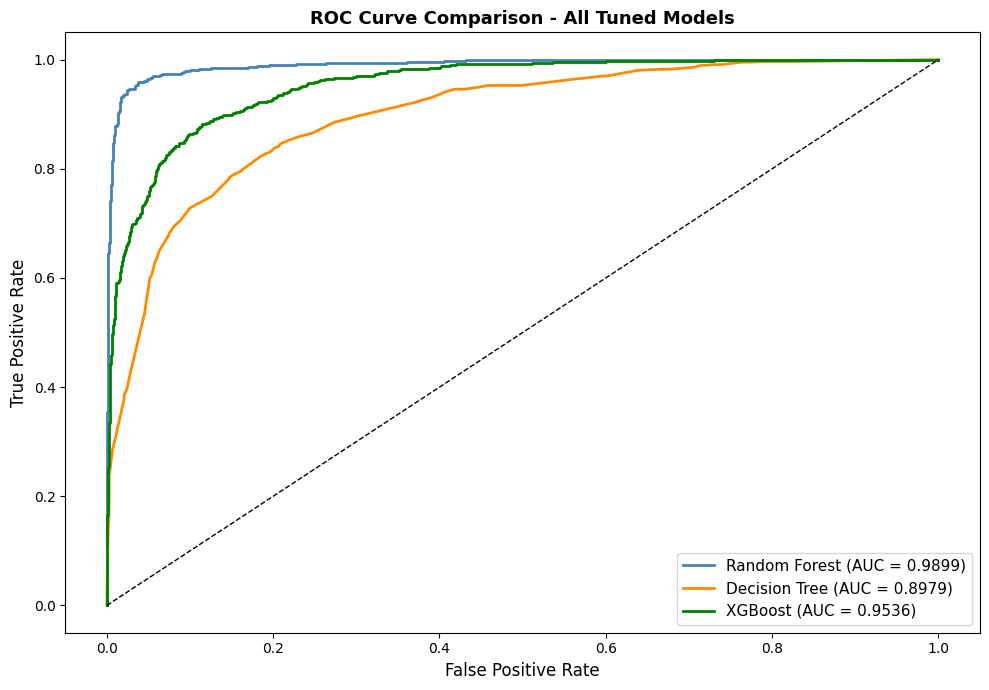

In [107]:
classes = np.unique(y_test_a_o_a_f)
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(10, 7))
for (name, y_test, _, y_proba), color in zip(models_eval, colors):
    y_bin = label_binarize(y_test, classes=np.unique(y_test))
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_proba.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison - All Tuned Models", fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

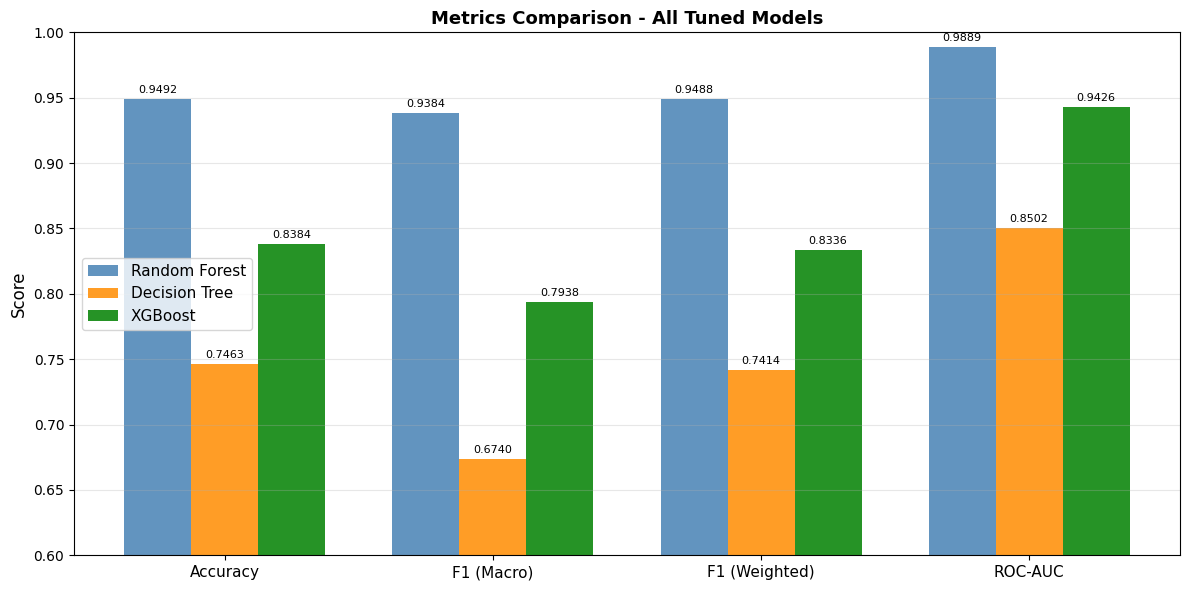

In [108]:
df_plot = df_results.reset_index()
metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'darkorange', 'green']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(df_plot.iterrows()):
    bars = ax.bar(x + i * width, [row[m] for m in metrics],
                  width, label=row['Model'], color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{bar.get_height():.4f}",
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0.6, 1.0)
ax.set_title("Metrics Comparison - All Tuned Models", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

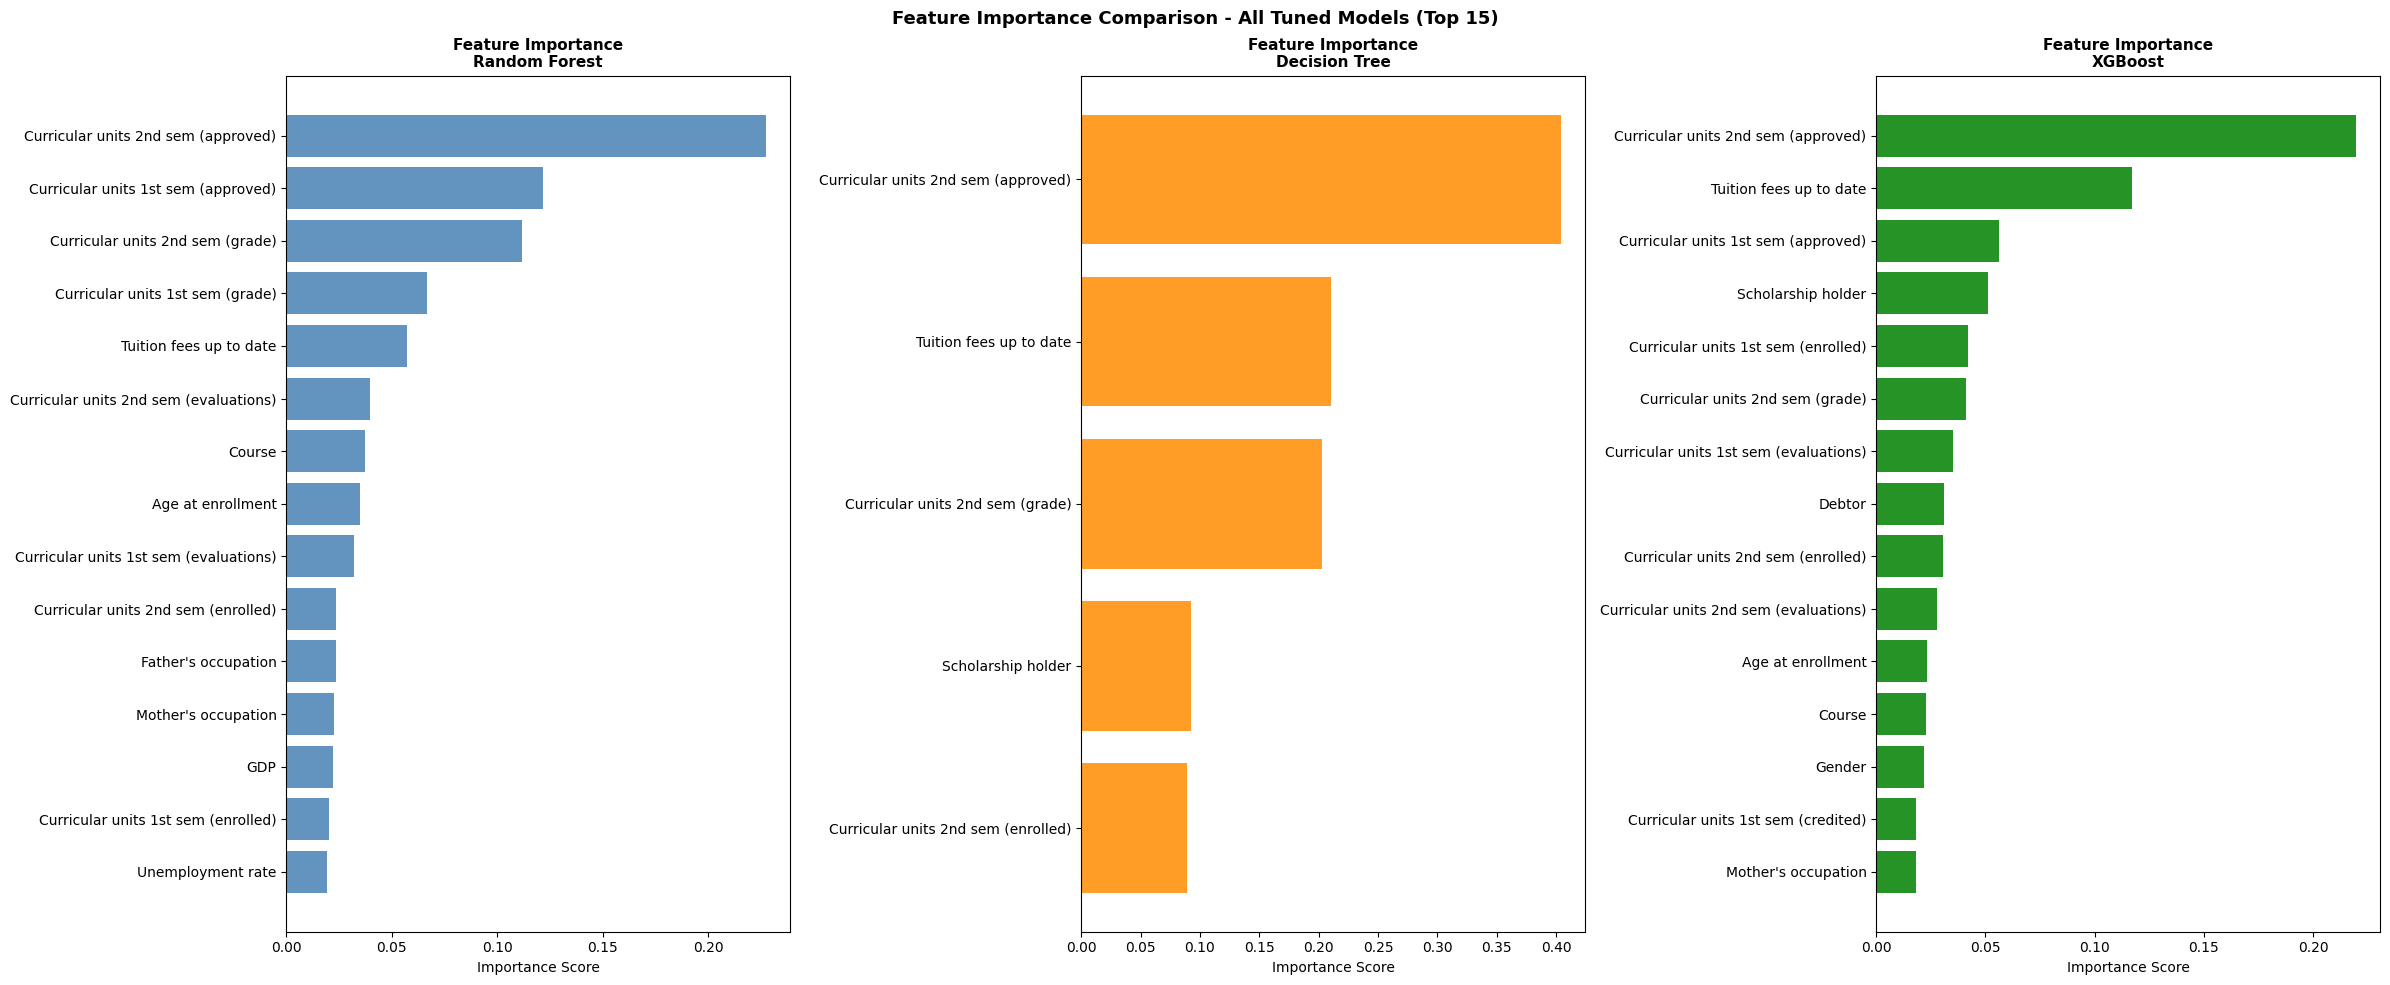

In [109]:
fi_configs = [
    ("Random Forest", best_rf_model, X_train_a_o_a_f.columns, 'steelblue'),
    ("Decision Tree", best_dt_model, X_train_n_o_s_f.columns, 'darkorange'),
    ("XGBoost", best_xgb_model, X_train_a_o_a_f.columns, 'green'),
]

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
for idx, (name, model, feature_names, color) in enumerate(fi_configs):
    fi_df = pd.DataFrame({
        'Feature' : feature_names,
        'Importance' : model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(15)  # top 15

    axes[idx].barh(fi_df['Feature'], fi_df['Importance'], color=color, alpha=0.85)
    axes[idx].set_title(f"Feature Importance\n{name}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Importance Score")

plt.suptitle("Feature Importance Comparison - All Tuned Models (Top 15)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [110]:
print("="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)
print(df_results.to_string())
best_model_name = df_results['ROC-AUC'].idxmax()
print("="*60)
print()
print("="*60)
print(f"🏆 BEST OVERALL MODEL (by ROC-AUC): {best_model_name}")
print("="*60)
print(f"ROC-AUC  : {df_results.loc[best_model_name, 'ROC-AUC']}")
print(f"Accuracy : {df_results.loc[best_model_name, 'Accuracy']}")
print(f"F1 (Weighted): {df_results.loc[best_model_name, 'F1 (Weighted)']}")
print("="*60)

FINAL MODEL COMPARISON SUMMARY
               Accuracy  F1 (Macro)  F1 (Weighted)  ROC-AUC
Model                                                      
Random Forest    0.9492      0.9384         0.9488   0.9889
Decision Tree    0.7463      0.6740         0.7414   0.8502
XGBoost          0.8384      0.7938         0.8336   0.9426

🏆 BEST OVERALL MODEL (by ROC-AUC): Random Forest
ROC-AUC  : 0.9889
Accuracy : 0.9492
F1 (Weighted): 0.9488
